# Markov Chain Monte Carlo applied to dark energy

The **Markov Chain Monte Carlo (MCMC)** methods are a family of algorithms used to sample probability distributions and evaluate uncertainties accurately. In this work these methods are used to provide estimates of the key cosmological parameters, such as the Hubble parameter and the matter and energy densities of the universe.

## Key concepts:
 - Markov chain: A process whose future depends only on the current state, not on the previous ones.
 - Metropolis–Hastings: Generates new samples through random proposals and accepts or rejects them with a probability that depends on the target distribution.

We import the required libraries.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd

np.random.seed(42)  # reproducibility

Let's look at a plot. We now import the data.

In [ ]:
dataHz = pd.read_csv("data/hubble_cosmic_chronometers.txt", sep=' ', header=None, comment='#')

We now separate the data: **redshift**, **observations** and **errors**.

In [3]:
redshift, obs, errors = [dataHz[i] for i in range(0,3)]

First we plot the observational data:

In [ ]:
zvals = np.linspace(0,2.2,220)
plt.errorbar(redshift,obs, yerr=errors, fmt='o',capsize=5, color='navy',ms=5, label="Obs. data")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(color='lightgray',alpha=0.5,zorder=1)

plt.ylabel("$H(z)$ [$km \\cdot s^{-1}/Mpc$]")
plt.xlabel("$z$")
plt.legend()
plt.title("Evolution of $H(z)$")
plt.savefig("figures/observational_data.png")
plt.show()

We can write $H$ using the (1st) Friedmann equation in the $\Lambda$-CDM model:
$$ H^{2} = \frac{8\pi G}{3}\rho - \frac{kc^{2}}{a^{2}} + \frac{\Lambda c^{2}}{3} $$
and defining the density parameters
$$ \rho_{c} = \frac{3H_{0}^{2}}{8\pi G} $$
$$\Omega_{m} = \frac{8\pi G}{3H_{0}^{2}}\rho_{m0} $$
$$ \Omega_{k} = \frac{-kc^{2}}{(a_{0}H_{0})^{2}}  $$
$$ \Omega_{\Lambda} = \frac{\Lambda c^{2}}{3H_{0}^{2}}$$
we can then rewrite the 1st Friedmann equation as
$$ H(z)^{2} = H_{0}^{2}\left(\Omega_{m}(1+z)^{3}+\Omega_{k}(1+z)^{2} + \Omega_{\Lambda} \right) $$
Currently, $\Omega_{k}=0$ is assumed, so the equation becomes
$$ H(z)^{2} = H_{0}^{2}\left( \Omega_{m}(1+z)^{3} + (1-\Omega_{m} ) \right) $$

## The protagonist: Metropolis–Hastings

In [7]:
def chi_squared(model, current_state, observed_points, inv_cov):
    redshift, d_observed = observed_points
    diff = model(current_state)(redshift) - d_observed
    return diff @ inv_cov @ diff 

In [8]:
def likelihood(chi2):
    return np.exp(-chi2 / 2)

In [9]:
def updater(chain, current_state, proposal_std, current_likelihood, likelihood, model, observed_points, inv_cov):
    proposed_state = np.random.normal(current_state, proposal_std)
    proposed_likelihood = likelihood(chi_squared(model, proposed_state, observed_points, inv_cov))#(model, proposed_state, observed_points, inverse_covariance_matrix)
    accept_criterion = proposed_likelihood / current_likelihood

    if proposed_likelihood >= current_likelihood or np.random.rand() < proposed_likelihood / current_likelihood:
        return proposed_state, proposed_likelihood

    return current_state, current_likelihood

In [10]:
def metropolis_hastings(n_steps, initial_parameters, proposal_std, model, observed_points, covariance_matrix):
    chain = []
    inv_cov = np.linalg.inv(covariance_matrix)
    current_state = initial_parameters
    current_likelihood = likelihood(chi_squared(model, current_state, observed_points, inv_cov))
    
    #current_likelihood = likelihood(model, current_state, observed_points, inv_cov)

    for _ in range(n_steps):
        current_state, current_likelihood = updater(chain, current_state, proposal_std, current_likelihood, likelihood, model, observed_points, inv_cov)
        chain.append(current_state)
    return chain

## $\Lambda$-CDM model

$$ H(z)^{2} = H_{0}^{2}\left(\Omega_{m}(1+z)^{3} + (1-\Omega_{m} \right)(1+z)^{3(1+w)}$$

In [27]:
def generalized_model(current_state, model_params, model_expr):
    def Hz(z):
        # Evaluate the custom expression using the given parameters
        inner_expression = model_expr(current_state, z, model_params)
        return current_state[0] * np.sqrt(np.maximum(inner_expression, 0))  # Ensure non-negative
    return Hz

In [28]:
def ΛCDM_expression(current_state, z, model_params):
    Ω_m, = model_params
    return Ω_m * (1 + z) ** 3 + (1 - Ω_m)

In [29]:
def ΛCDM_model(current_state):
    Ω_m = current_state[1]  # Extract Ω_m from current_state
    return generalized_model(current_state, (Ω_m,), ΛCDM_expression)

In [30]:
observed, covariance_matrix = [redshift, obs], np.diag(errors)

In [31]:
chain_ΛCDM = metropolis_hastings(int(1e4), [70, 0.3], [10, 0.1], ΛCDM_model, observed, covariance_matrix)

In [32]:
z_vals = np.arange(0,2,0.1)
model_predictions =  np.array(ΛCDM_model(chain_ΛCDM[-1])(np.arange(0,2,0.1)))

In [33]:
# 1σ (68%) interval
lower_1sigma = np.percentile(model_predictions, 16, axis=0)
upper_1sigma = np.percentile(model_predictions, 84, axis=0)

# 2σ (95%) interval
lower_2sigma = np.percentile(model_predictions, 2.5, axis=0)
upper_2sigma = np.percentile(model_predictions, 97.5, axis=0)

In [ ]:
plt.errorbar(redshift,obs, yerr=errors, fmt='o',capsize=5, color='#021526',ms=5, label="Obs. data")
plt.plot(np.arange(0,2,0.1), ΛCDM_model(chain_ΛCDM[-1])(np.arange(0,2,0.1)), color='#03346E', label=r"$\Lambda$-CDM model")

# Display the Ω_m and H_0 values from chain_ΛCDM[-1]
parameters_text = rf"$\Omega_m$: {chain_ΛCDM[-1][1]:.2f}, $H_0$: {chain_ΛCDM[-1][0]:.2f} km/s Mpc"
plt.text(0.05, 0.9, parameters_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='white'))

plt.ylabel("$H(z)$ [$km \\cdot s^{-1}/Mpc$]")
plt.xlabel("$z$")
plt.title("Evolution of $H(z)$")
plt.grid(True)
plt.legend()
plt.savefig("figures/observational_data_LCDM.png")
plt.show()

In [35]:
import seaborn as sns

In [ ]:
# Generate redshift values for plotting
zvals = np.linspace(0, 2, 100)

# Get model predictions for each sample in the chain (ΛCDM model)
model_predictions = np.array([ΛCDM_model(params)(zvals) for params in chain_ΛCDM])

# Calculate the median and confidence intervals
median_prediction = np.median(model_predictions, axis=0)

# 1σ (68%) interval
lower_1sigma = np.percentile(model_predictions, 16, axis=0)
upper_1sigma = np.percentile(model_predictions, 84, axis=0)

# 2σ (95%) interval
lower_2sigma = np.percentile(model_predictions, 2.5, axis=0)
upper_2sigma = np.percentile(model_predictions, 97.5, axis=0)

# Plot the observational data
plt.errorbar(redshift, obs, yerr=errors, fmt='o', capsize=5, color='navy', label="Obs. data", ms=5)

# Plot the model's median prediction
plt.plot(zvals, median_prediction, color='black', label=r"$\Lambda$-CDM model")

# Plot the 2σ confidence interval as a shaded region
plt.fill_between(zvals, lower_2sigma, upper_2sigma, color='gray', alpha=0.2, label="2σ confidence interval (95%)")

# Plot the 1σ confidence interval as a shaded region
plt.fill_between(zvals, lower_1sigma, upper_1sigma, color='gray', alpha=0.5, label="1σ confidence interval (68%)")

# Customize plot
plt.xlabel("z")
plt.ylabel("H(z)")
plt.legend()
plt.title("Evolution of $H(z)$ with confidence intervals")
plt.grid(True)
plt.savefig("figures/LCDM_confidence_intervals.png")
plt.show()

In [37]:
import seaborn as sns
from scipy import stats

In [38]:
def extract_data(chain, index):
    return [chain[i][index] for i in range(len(chain))]

In [39]:
H0_ΛCDM_data, Ωm_ΛCDM_data = extract_data(chain_ΛCDM, 0),  extract_data(chain_ΛCDM, 1)

In [40]:
def create_marginal(x_data, y_data, x_name, y_name):
    sns.set(style="whitegrid", context="paper")
    g = sns.JointGrid(x= x_data, y = y_data)
    g.plot_marginals(sns.histplot, kde=True, color="Blue", bins=30, discrete=False)
    g.plot_joint(sns.kdeplot, fill=True, cmap="Blues", levels=4, thresh=0.0005)
    g.ax_marg_x.axvline(stats.mode(x_data)[0], color="#0C134F", linestyle="--")
    g.ax_marg_y.axhline(stats.mode(y_data)[0], color="#0C134F", linestyle="--")
    g.set_axis_labels(f"${x_name}$", f"${y_name}$", fontsize=14)
    plt.show()

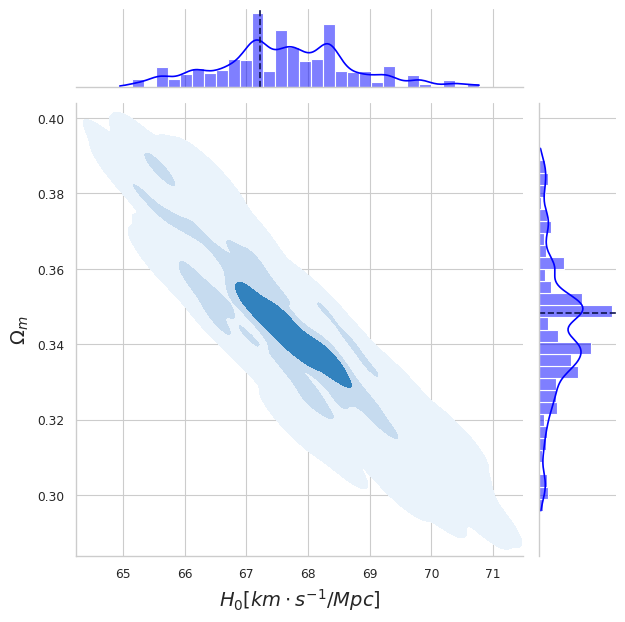

In [42]:
create_marginal(H0_ΛCDM_data, Ωm_ΛCDM_data, "H_0 [km \\cdot s^{-1}/Mpc]", "\\Omega_{m}")

## Alternatives to the $\Lambda$-CDM model

An alternative to modelling dark energy as a cosmological constant comes from the equation of state in cosmology:
$$ \rho = \frac{p}{\rho} $$

$$w = \frac{p}{\rho} $$

### CPL model

$$ H(z)^{2} = H_{0}^{2}\left(\Omega_m \cdot (1 + z)^3 + (1 - \Omega_m) \cdot (1 + z)^{3(1 + w_0 + w_{a}) \cdot e^{-3w_{a} \left(\frac{z}{z+1}\right)}} \right)$$

In [ ]:
# CPL model
def CPL_Model(current_state):
    H_0, Ω_m, w0, w1 = current_state
    def Hz(z):
        inner_expression = Ω_m * (1 + z) ** 3 + (1 - Ω_m)*(1+z)**(3*(1+w0+w1)*np.exp(-3*w1*(z/(z+1))))
        return H_0 * np.sqrt(np.maximum(inner_expression, 0))  # Ensure non-negative
    return Hz

In [44]:
chain_CPL = metropolis_hastings(int(1e4),[70, 0.3,-0.9,0.01], [2.5, 0.25,0.3,0.3], CPL_Model, observed, covariance_matrix)

In [ ]:
plt.errorbar(redshift, obs, yerr=errors,fmt='o', capsize=5, label="Obs. data", color="#0C134F")
plt.plot(np.arange(0,2,0.1), CPL_Model(chain_CPL[-1])(np.arange(0,2,0.1)), color='#1D267D',linestyle="--", label=r"CPL model")
plt.plot(np.arange(0,2,0.1), ΛCDM_model(chain_ΛCDM[-1])(np.arange(0,2,0.1)), color='#D4ADFC', label=r"$\Lambda$-CDM model")

# Annotate the chain_CPL[-1] and chain_ΛCDM[-1] values in the plot
parameters_text_CPL = rf"CPL: $\Omega_m$: {chain_CPL[-1][1]:.2f} $H_0$: {chain_CPL[-1][0]:.2f} km/sMpc"
parameters_text_ΛCDM = rf"$\Lambda$-CDM: $\Omega_m$: {chain_ΛCDM[-1][1]:.2f} $H_0$: {chain_ΛCDM[-1][0]:.2f} km/s Mpc"

# Position the text in the plot
plt.text(0.03, 0.9, parameters_text_CPL, transform=plt.gca().transAxes, fontsize=7, 
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='white'))
plt.text(0.03, 0.8, parameters_text_ΛCDM, transform=plt.gca().transAxes, fontsize=7, 
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='white'))

plt.xlabel("z")
plt.ylabel("$H(z)$ [$km \\cdot s^{-1}/Mpc$]")
plt.title("Evolution of $H(z)$")
plt.legend()
plt.grid(True)
plt.savefig("figures/LCDM_CPL_comparison.png")
plt.show()

In [46]:
H0_CPL_data, Ωm__CPL_data, w0_CPL_data, w1_CPL_data = [extract_data(chain_CPL,i) for i in range(0,4)]

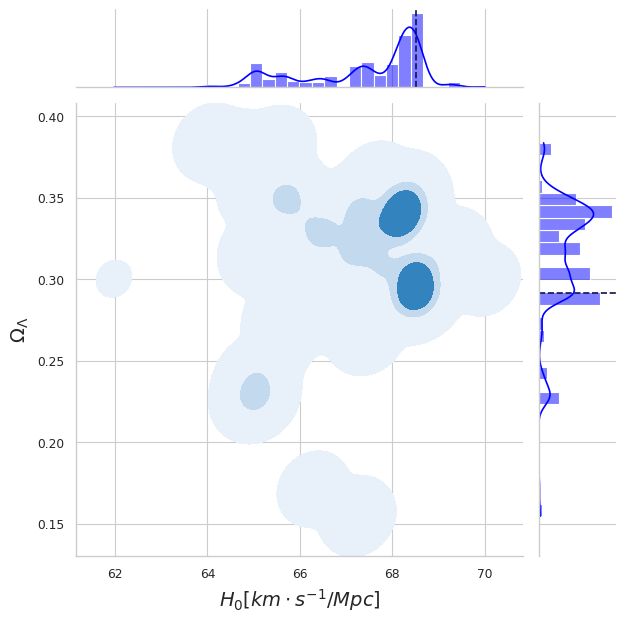

In [47]:
create_marginal(H0_CPL_data, Ωm__CPL_data, "H_0 [km \\cdot s^{-1}/Mpc]", "\\Omega_{\\Lambda}")

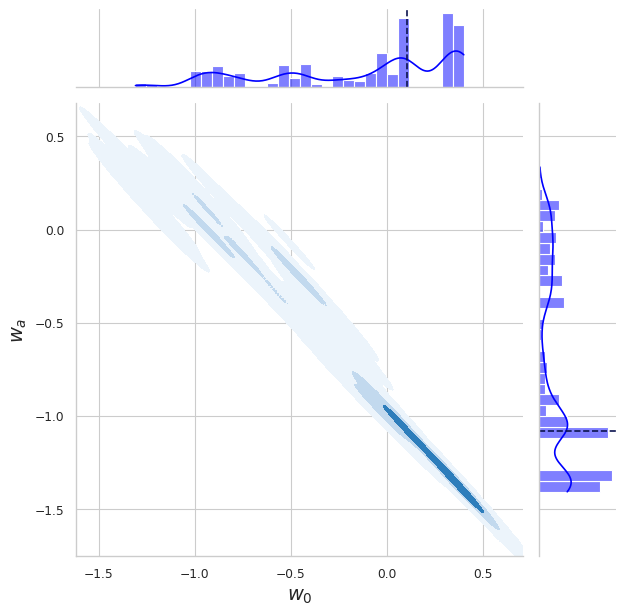

In [48]:
create_marginal(w0_CPL_data, w1_CPL_data, "w_0", "w_a")

In [105]:
w0_CPL_data[-1]
w1_CPL_data[-1]

0.20521060193520183

## References

Yu, H., Ratra, B., & Wang, F. Y. (2018). Hubble parameter and Baryon Acoustic Oscillation measurement constraints on the Hubble constant, the deviation from the spatially flat ΛCDM model, the deceleration–acceleration transition redshift, and spatial curvature. The Astrophysical Journal, 856(1), 3.

Bengaly, C., Dantas, M. A., Casarini, L., & Alcaniz, J. (2023). Measuring the Hubble constant with cosmic chronometers: a machine learning approach. The European Physical Journal C, 83(6), 1-13.

Gómez-Vargas, I., Medel-Esquivel, R., García-Salcedo, R., & Vázquez, J. A. (2023). Neural network reconstructions for the Hubble parameter, growth rate and distance modulus. The European Physical Journal C, 83(4), 304.